## imports

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# load dataset

In [2]:
# Load dataset
df = pd.read_csv('../Loan_Data.csv')

print(df.head())

print(df.dtypes)

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

# Feature Selection and feature enginnering

In [3]:
# Combining incomes
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# Remove rows where the target 'LoanAmount' is NaN
df = df.dropna(subset=['LoanAmount','ApplicantIncome','CoapplicantIncome'])

X = df.drop(['Loan_ID', 'LoanAmount'], axis=1)
y = df['LoanAmount']

# Data pre processing and cleaning

In [4]:
# Separate columns by type
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

num_cols = [col for col in num_cols if col not in ['LoanAmount', 'Loan_ID']]
cat_cols = [col for col in cat_cols if col not in ['LoanAmount', 'Loan_ID']]

# Fill numeric gaps with Median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical gaps with Mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

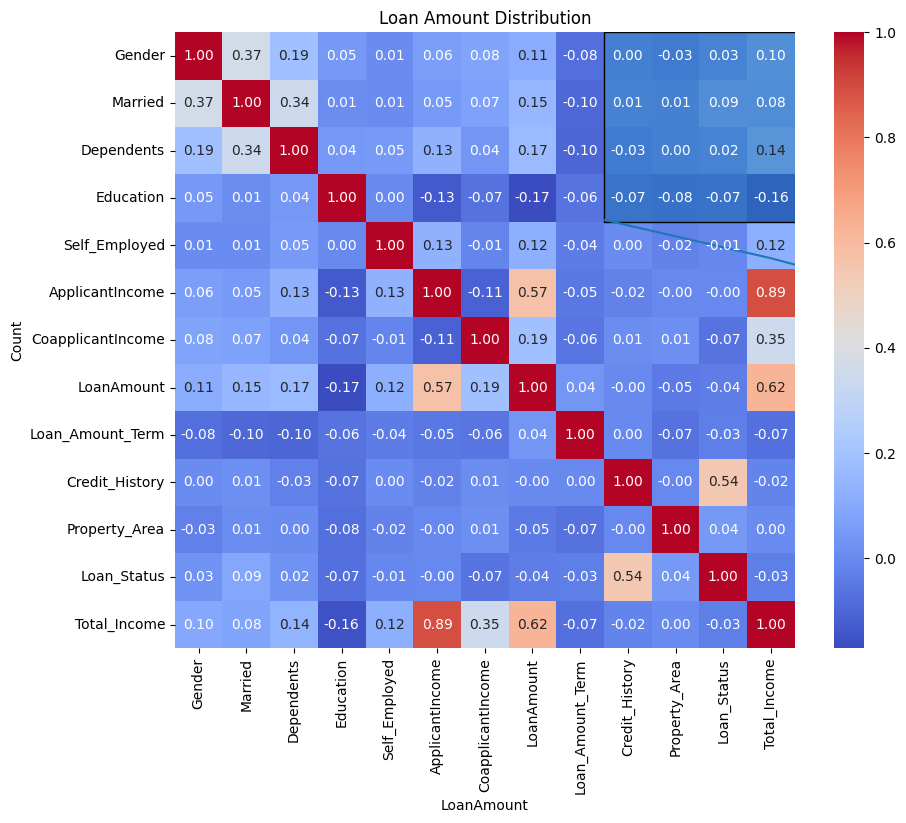

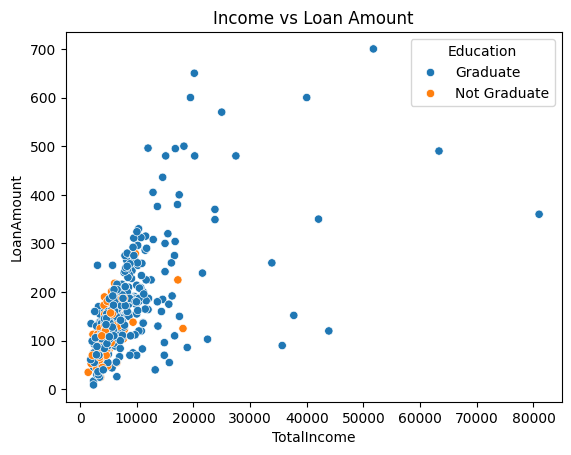

In [5]:
df_clean = df.copy()
df_clean['Dependents'] = df_clean['Dependents'].replace('3+', '3').astype(float)
df_clean['LoanAmount'] = df_clean['LoanAmount'].fillna(df_clean['LoanAmount'].median())
df_clean['Credit_History'] = df_clean['Credit_History'].fillna(df_clean['Credit_History'].mode()[0])

# Correlation Heatmap
plt.figure(figsize=(10, 8))
# Select only numeric for correlation
# We need to encode some cats to see correlation
df_encoded = df_clean.copy()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

corr = df_encoded.drop('Loan_ID', axis=1).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')

#  Check for Skewness in Target
sns.histplot(df['LoanAmount'].dropna(), kde=True)
plt.title('Loan Amount Distribution')
plt.show()

# Check for Linear Relationship
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
sns.scatterplot(data=df, x='TotalIncome', y='LoanAmount', hue='Education')
plt.title('Income vs Loan Amount')
plt.show()

# Data Pipeline

In [6]:
# Numeric Pipeline: Impute missing with median and scale
from sklearn.ensemble import RandomForestRegressor


numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Pipeline: Impute missing with mode and One-Hot Encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Combine transformers into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])


# Linear Regression apply

In [7]:
# 4. Model Selection & Training (Step 6)
# Create the full pipeline with Linear Regression
lr_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])


# 5. Split the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the model
lr_model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'Loan_Amount_Term',
                                                   'Credit_History',
                                                   'Total_Income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Dependents', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area',
                                                   'Loan_Status'])])),
                ('regressor', LinearRegression())])

In [8]:
y_pred = lr_model_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- Model Performance ---")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

# 3. Calculate "Accuracy" Percentage (Optional)
# In regression, we can look at the Mean Absolute Percentage Error
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Model Accuracy: {100 - mape:.2f}%")

--- Model Performance ---
Mean Absolute Error: 36.99
Root Mean Squared Error: 57.79
Mean Absolute Percentage Error (MAPE): 35.55%
Model Accuracy: 64.45%


loan amount is not linearly distributed.so best alogirthum is for this dataset randomforest 

# Random Forerst apply

In [9]:
# Create the full pipeline with Linear Regression
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=2500,      # Number of trees
        max_depth=10,          # Prevents overfitting
        min_samples_split=5,   # Higher value prevents learning noise
        random_state=42
    ))
])

# 5. Split the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the model
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'Loan_Amount_Term',
                                                   'Credit_History',
                                                   'Total_Income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Dependents', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area',
                                                   'Loan_Status'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=10, min_samples_split=5,
                                       n_estimators=2500, random_state=42))])

 Model Evaluation 

In [10]:
y_pred = model_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- Model Performance ---")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

# 3. Calculate "Accuracy" Percentage (Optional)
# In regression, we can look at the Mean Absolute Percentage Error
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Model Accuracy: {100 - mape:.2f}%")

--- Model Performance ---
Mean Absolute Error: 35.40
Root Mean Squared Error: 59.21
Mean Absolute Percentage Error (MAPE): 31.91%
Model Accuracy: 68.09%


# save model locally

In [11]:


# Create a folder named 'models' if it doesn't exist
folder_name = '../models'
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

# Save the entire pipeline (Preprocessing + Linear Regression)
model_path = os.path.join(folder_name, 'loan_price_model.pkl')
joblib.dump(model_pipeline, model_path)

print(f"Model saved successfully at: {model_path}")



Model saved successfully at: ../models/loan_price_model.pkl


# prediction

In [12]:

# 1. Load the saved model
loaded_model = joblib.load('../models/loan_price_model.pkl')

# 2. Prepare new data (Must be a DataFrame with same column names as X)
# Example of one new applicant
new_data = pd.DataFrame({
    'Gender': ['Male'],
    'Married': ['Yes'],
    'Dependents': ['1'],
    'Education': ['Graduate'],
    'Self_Employed': ['No'],
    'ApplicantIncome': [5000],
    'CoapplicantIncome': [2000],
    'Loan_Amount_Term': [360],
    'Credit_History': [1.0],
    'Property_Area': ['Urban'],
    'Loan_Status': ['Y']
})

new_data['Total_Income'] = new_data['ApplicantIncome'] + new_data['CoapplicantIncome']

# 3. Predict the LoanAmount
prediction = loaded_model.predict(new_data)

print(f"Predicted Loan Amount: {prediction[0]:.2f}")

Predicted Loan Amount: 145.71
